## Sección 1 – Instalación de Dependencias

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn scipy -q
print('✅ Librerías instaladas')

✅ Librerías instaladas


##  Sección 2 – Importación de Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                              davies_bouldin_score, calinski_harabasz_score)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

COLORS = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6',
          '#1abc9c','#e67e22','#34495e','#e91e8c','#00bcd4']

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## Ejercicio 4: Agrupamiento de clientes

> **Instrucciones:**  
> 1. Descarga `Mall_Customers.csv` de Kaggle  
> 2. Ejecuta la celda — aparecerá un botón **"Elegir archivos"**  
> 3. Selecciona tu archivo CSV y listo

In [3]:
from google.colab import files
import io

print('📂 Sube tu archivo Mall_Customers.csv:')
uploaded = files.upload()

# Leer el CSV subido
nombre_archivo = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[nombre_archivo]))

print(f'\n✅ Archivo cargado: {nombre_archivo}')
print(f'   Filas    : {df.shape[0]}')
print(f'   Columnas : {df.shape[1]}')
print(f'   Nombres  : {list(df.columns)}')

📂 Sube tu archivo Mall_Customers.csv:


Saving Mall_Customers.csv to Mall_Customers.csv

✅ Archivo cargado: Mall_Customers.csv
   Filas    : 200
   Columnas : 5
   Nombres  : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


##  Sección 4 – Exploración Inicial del Dataset

In [4]:
print('── Primeras 10 filas ──')
display(df.head(10))

── Primeras 10 filas ──


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [5]:
print('── Información general ──')
df.info()

── Información general ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
print('── Estadísticas descriptivas ──')
display(df.describe().round(2))

print('\n── Valores nulos por columna ──')
print(df.isnull().sum())

print('\n── Distribución por género ──')
print(df['Gender'].value_counts())

── Estadísticas descriptivas ──


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00



── Valores nulos por columna ──
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

── Distribución por género ──
Gender
Female    112
Male       88
Name: count, dtype: int64


##  Sección 5 – Análisis Exploratorio de Datos (EDA)

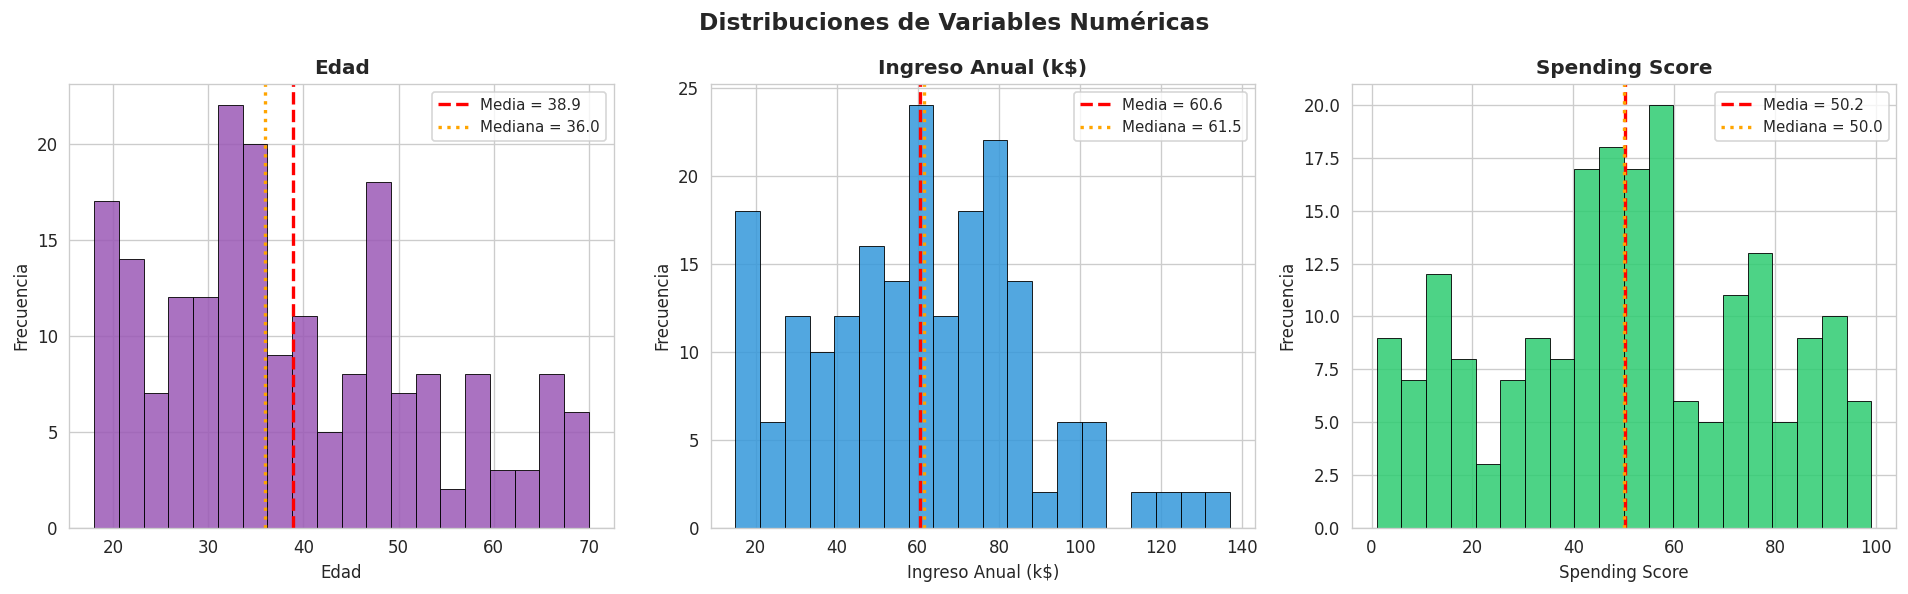

✅ Guardado: ej4_distribuciones.png


In [9]:
# ── 5.1 Distribuciones univariadas ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribuciones de Variables Numéricas', fontsize=14, fontweight='bold')

vars_info = [
    ('Age',                    '#9b59b6', 'Edad'),
    ('Annual Income (k$)',     '#3498db', 'Ingreso Anual (k$)'),
    ('Spending Score (1-100)', '#2ecc71', 'Spending Score'),
]

for ax, (var, color, titulo) in zip(axes, vars_info):
    ax.hist(df[var], bins=20, color=color, edgecolor='black', alpha=0.85, linewidth=0.6)
    ax.axvline(df[var].mean(),   color='red',    linestyle='--', lw=2,
               label=f'Media = {df[var].mean():.1f}')
    ax.axvline(df[var].median(), color='orange', linestyle=':',  lw=2,
               label=f'Mediana = {df[var].median():.1f}')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(titulo)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('ej4_distribuciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ej4_distribuciones.png')

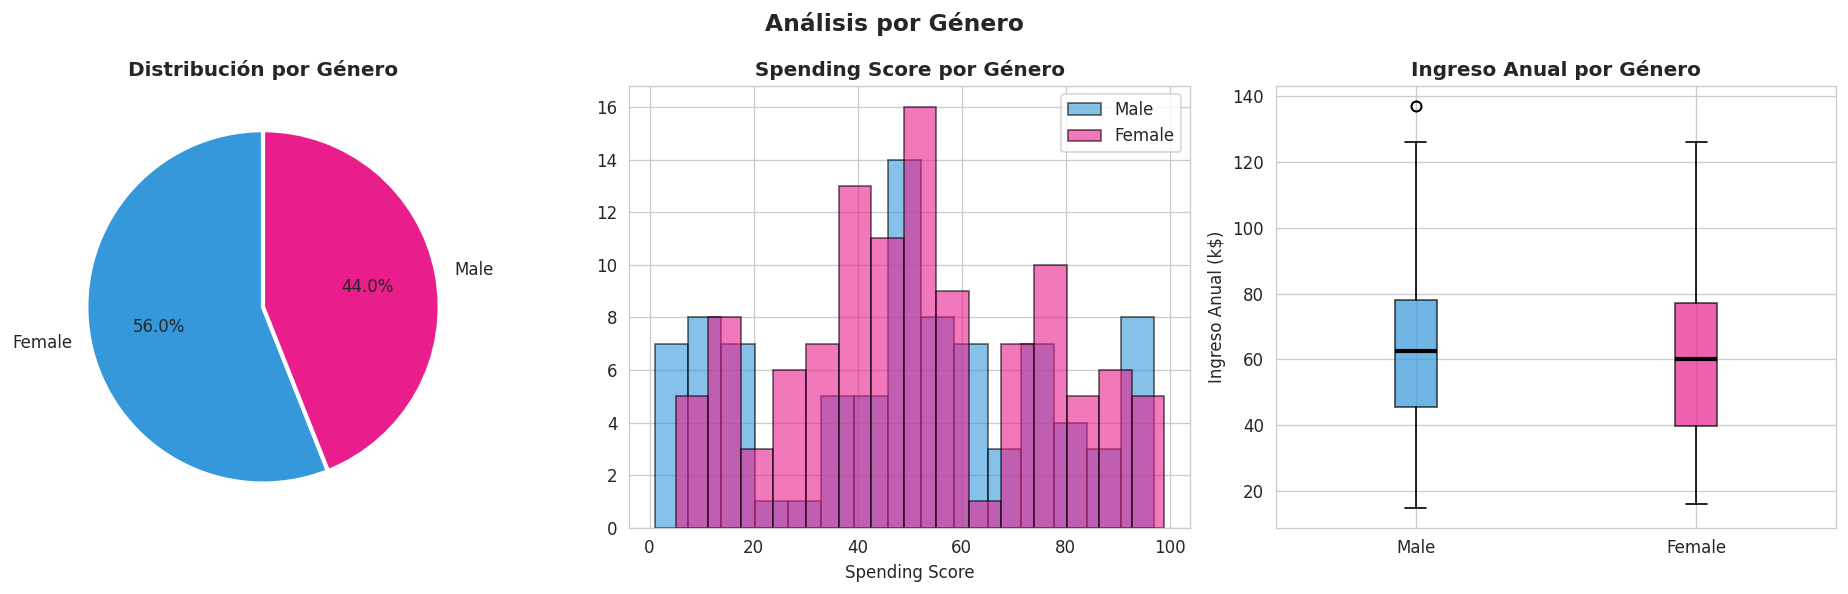

✅ Guardado: ej4_genero.png


In [11]:
# ── 5.2 Análisis por género ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis por Género', fontsize=14, fontweight='bold')

# Pie chart
counts = df['Gender'].value_counts()
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#3498db','#e91e8c'], startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2.5))
axes[0].set_title('Distribución por Género', fontweight='bold')

# Spending Score por género
for genero, color in zip(['Male','Female'], ['#3498db','#e91e8c']):
    data = df[df['Gender'] == genero]['Spending Score (1-100)']
    axes[1].hist(data, bins=15, alpha=0.6, color=color, label=genero, edgecolor='black')
axes[1].set_title('Spending Score por Género', fontweight='bold')
axes[1].set_xlabel('Spending Score')
axes[1].legend()

# Ingreso por género (boxplot)
bp = axes[2].boxplot(
    [df[df['Gender']=='Male']['Annual Income (k$)'],
     df[df['Gender']=='Female']['Annual Income (k$)']],
    labels=['Male','Female'], patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5)
)
bp['boxes'][0].set_facecolor('#3498db'); bp['boxes'][0].set_alpha(0.7)
bp['boxes'][1].set_facecolor('#e91e8c'); bp['boxes'][1].set_alpha(0.7)
axes[2].set_title('Ingreso Anual por Género', fontweight='bold')
axes[2].set_ylabel('Ingreso Anual (k$)')

plt.tight_layout()
plt.savefig('ej4_genero.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ej4_genero.png')

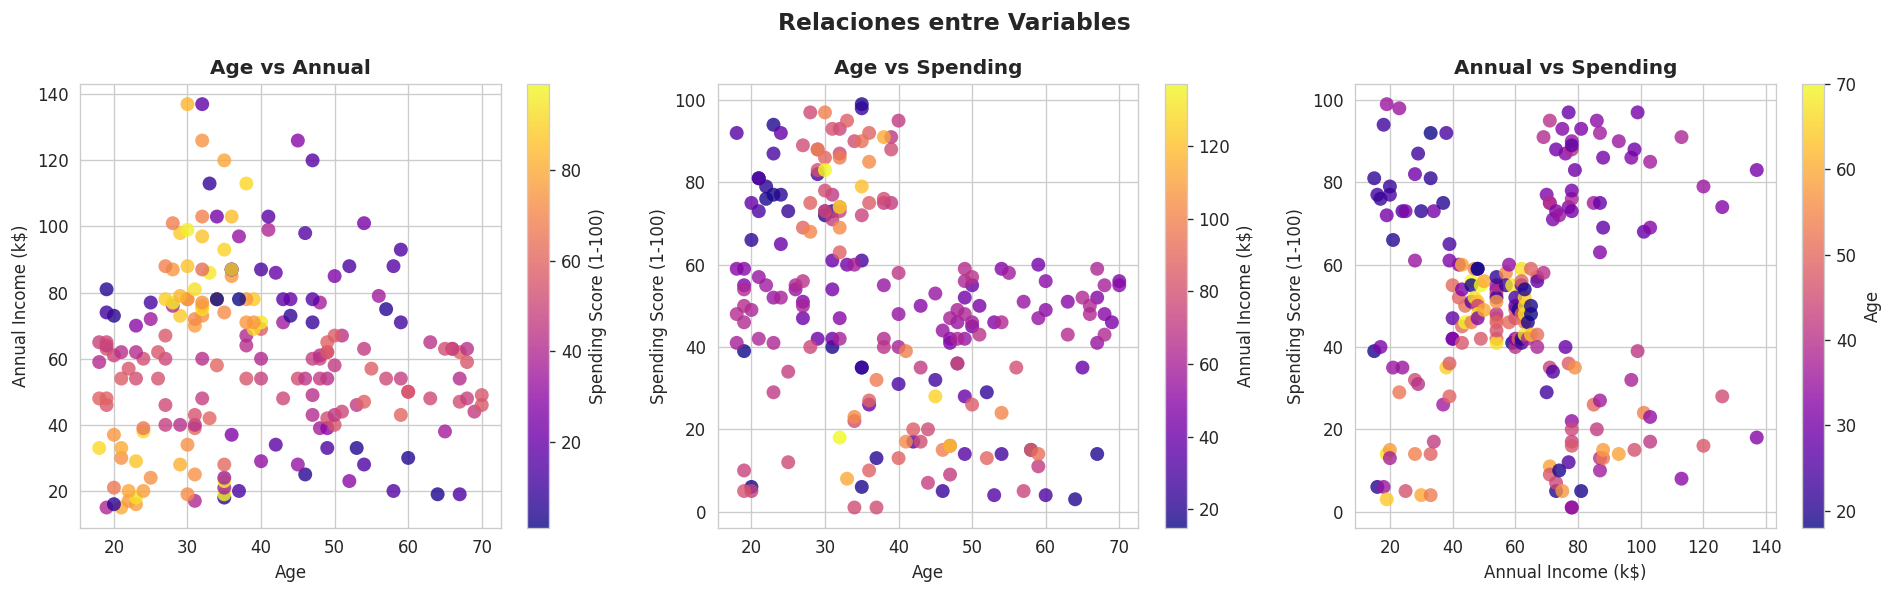

✅ Guardado: ej4_scatter.png


In [12]:
# ── 5.3 Scatter plots entre variables ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Relaciones entre Variables', fontsize=14, fontweight='bold')

pares = [
    ('Age',               'Annual Income (k$)',      'Spending Score (1-100)'),
    ('Age',               'Spending Score (1-100)',   'Annual Income (k$)'),
    ('Annual Income (k$)','Spending Score (1-100)',   'Age'),
]
for ax, (x, y, c) in zip(axes, pares):
    sc = ax.scatter(df[x], df[y], c=df[c], cmap='plasma',
                    s=70, alpha=0.8, edgecolors='none')
    plt.colorbar(sc, ax=ax, label=c)
    ax.set_xlabel(x); ax.set_ylabel(y)
    titulo = f'{x.split(" ")[0]} vs {y.split(" ")[0]}'
    ax.set_title(titulo, fontweight='bold')

plt.tight_layout()
plt.savefig('ej4_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ej4_scatter.png')

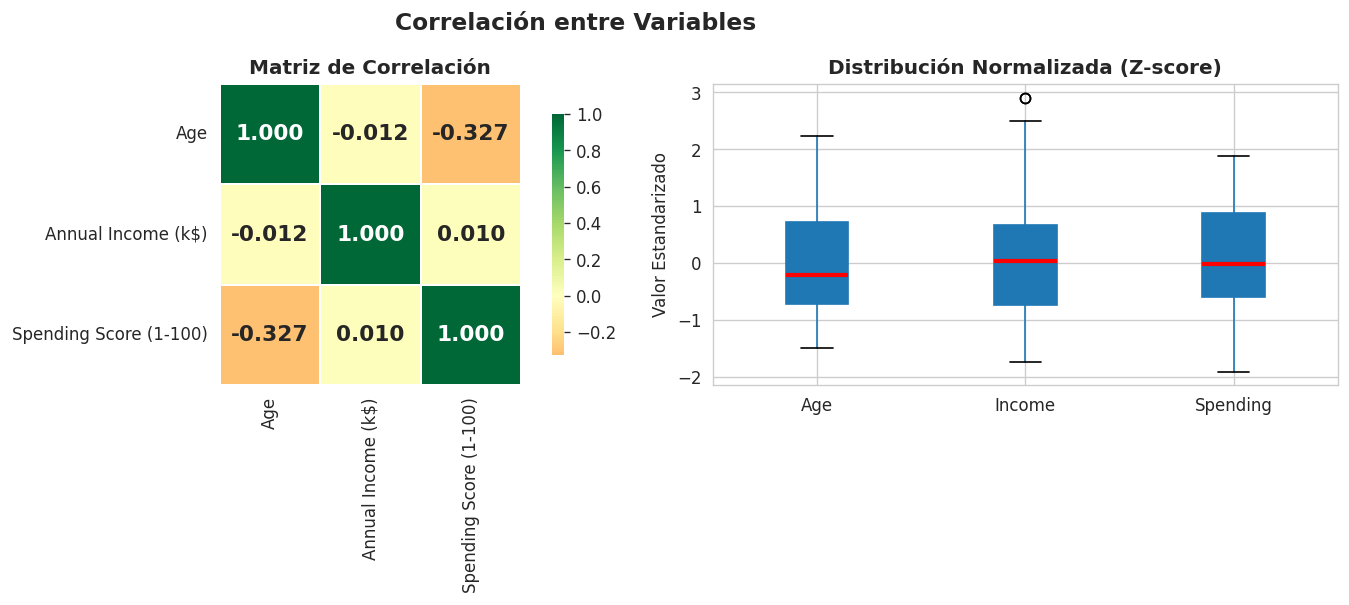

✅ Guardado: ej4_correlacion.png


In [13]:
# ── 5.4 Correlación ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Correlación entre Variables', fontsize=14, fontweight='bold')

cols_num = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
corr = df[cols_num].corr()

sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            ax=axes[0], linewidths=1, square=True,
            annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Matriz de Correlación', fontweight='bold')

# Boxplots normalizados
df_z = (df[cols_num] - df[cols_num].mean()) / df[cols_num].std()
df_z.boxplot(ax=axes[1], patch_artist=True,
             medianprops=dict(color='red', linewidth=2.5))
axes[1].set_title('Distribución Normalizada (Z-score)', fontweight='bold')
axes[1].set_ylabel('Valor Estandarizado')
axes[1].set_xticklabels(['Age','Income','Spending'], rotation=0)

plt.tight_layout()
plt.savefig('ej4_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ej4_correlacion.png')

##  Sección 6 – Preprocesamiento

In [15]:
# Codificar género
le = LabelEncoder()
df['Gender_enc'] = le.fit_transform(df['Gender'])  # Female=0, Male=1

# Features para clustering
features  = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X         = df[features].values

# Estandarización
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Preprocesamiento completado')
print(f'   Clientes        : {X.shape[0]}')
print(f'   Features usadas : {features}')
print(f'   Media escalada  : {X_scaled.mean(axis=0).round(5)}')
print(f'   Std escalada    : {X_scaled.std(axis=0).round(5)}')

✅ Preprocesamiento completado
   Clientes        : 200
   Features usadas : ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
   Media escalada  : [-0. -0. -0.]
   Std escalada    : [1. 1. 1.]


##  Sección 7 – Modelo 1: K-Means

**Justificación:** K-Means es el algoritmo de clustering más utilizado por su eficiencia computacional y su capacidad de encontrar grupos compactos y bien separados. Es ideal para segmentar clientes por ingreso y comportamiento de gasto.

In [16]:
# ── Búsqueda del K óptimo ────────────────────────────────────
print('🔍 Calculando métricas para k = 2 a 10...')

k_range     = range(2, 11)
inertias    = []
silhouettes = []
dbs         = []
chs         = []

for k in k_range:
    km  = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))
    dbs.append(davies_bouldin_score(X_scaled, lbl))
    chs.append(calinski_harabasz_score(X_scaled, lbl))
    print(f'   k={k}  Silhouette={silhouettes[-1]:.4f}  DB={dbs[-1]:.4f}  CH={chs[-1]:.1f}')

K_OPT = list(k_range)[np.argmax(silhouettes)]
print(f'\n✅ K óptimo: k = {K_OPT}  (Silhouette = {max(silhouettes):.4f})')

🔍 Calculando métricas para k = 2 a 10...
   k=2  Silhouette=0.3355  DB=1.2607  CH=107.1
   k=3  Silhouette=0.3578  DB=1.0503  CH=101.7
   k=4  Silhouette=0.4040  DB=0.9308  CH=125.7
   k=5  Silhouette=0.4166  DB=0.8746  CH=125.1
   k=6  Silhouette=0.4274  DB=0.8277  CH=135.1
   k=7  Silhouette=0.4172  DB=0.7935  CH=132.8
   k=8  Silhouette=0.4087  DB=0.8893  CH=131.1
   k=9  Silhouette=0.4201  DB=0.8541  CH=131.2
   k=10  Silhouette=0.3973  DB=0.9056  CH=133.4

✅ K óptimo: k = 6  (Silhouette = 0.4274)


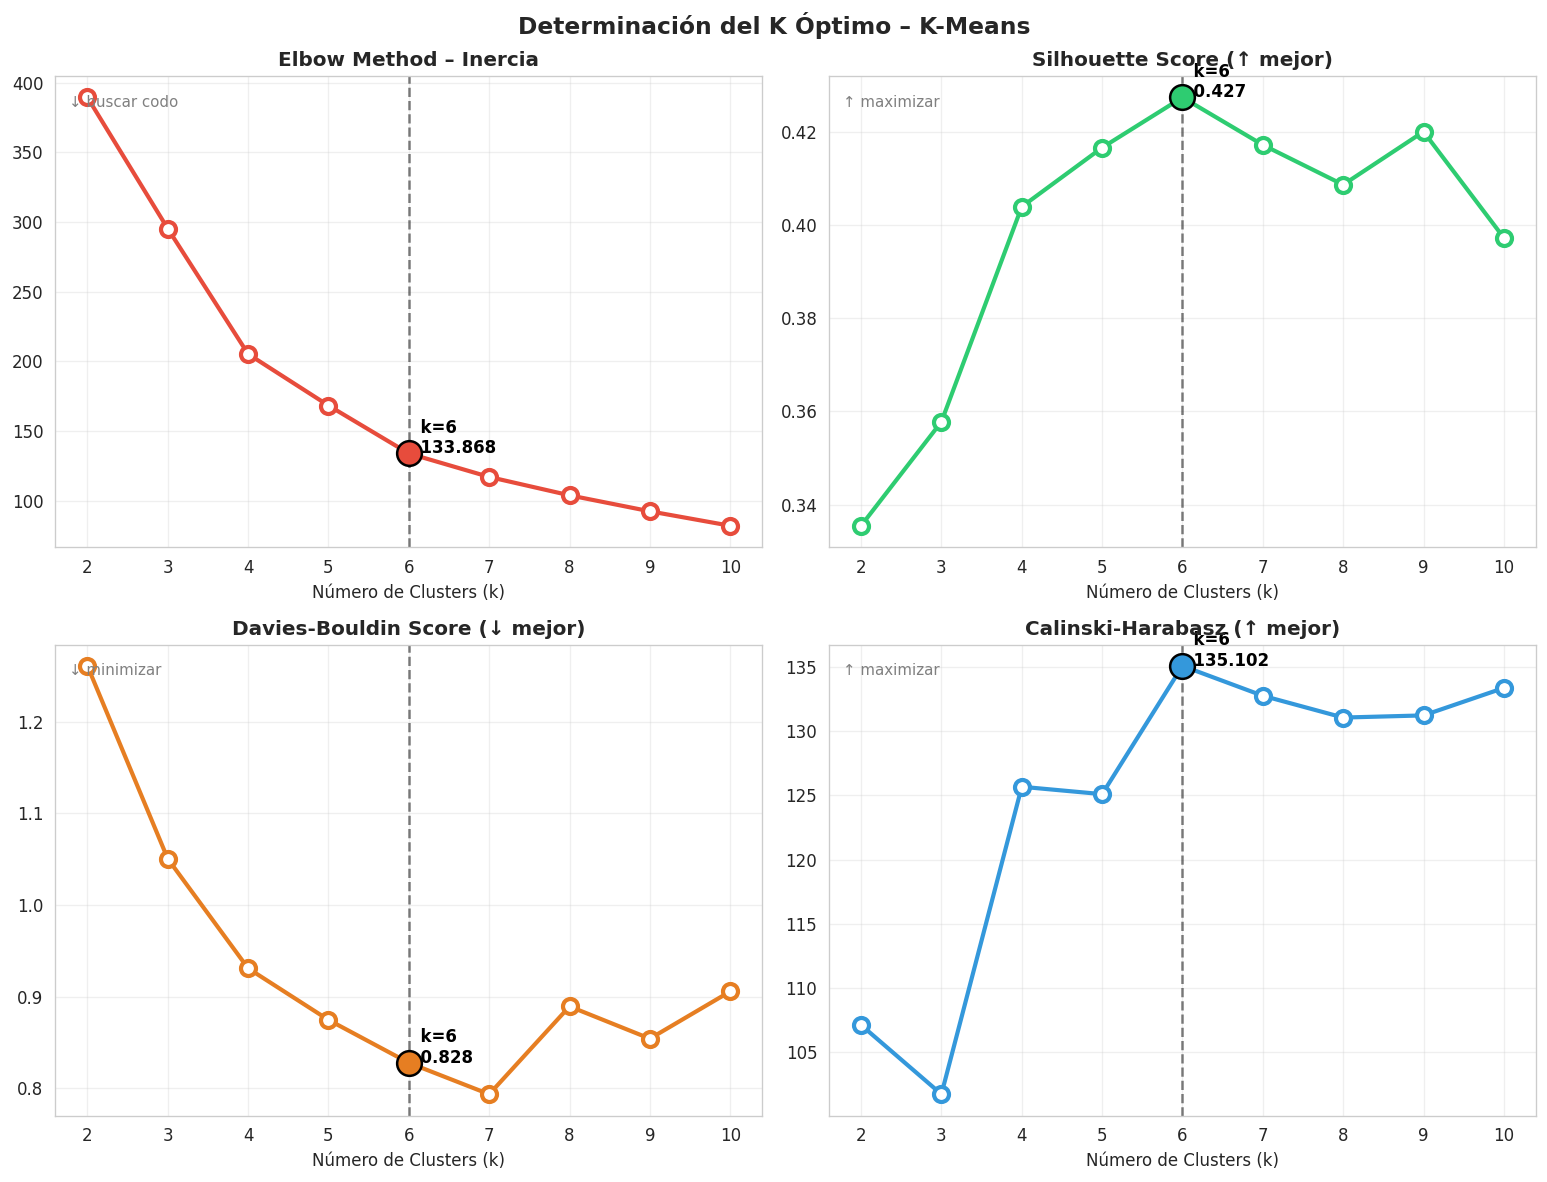

✅ Guardado: ej4_k_optimo.png


In [17]:
# ── Visualización del K óptimo ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Determinación del K Óptimo – K-Means', fontsize=14, fontweight='bold')

metricas_k = [
    ('Elbow Method – Inercia',        inertias,    '#e74c3c', '↓ buscar codo'),
    ('Silhouette Score (↑ mejor)',     silhouettes, '#2ecc71', '↑ maximizar'),
    ('Davies-Bouldin Score (↓ mejor)', dbs,         '#e67e22', '↓ minimizar'),
    ('Calinski-Harabasz (↑ mejor)',    chs,         '#3498db', '↑ maximizar'),
]

for ax, (titulo, datos, color, nota) in zip(axes.flat, metricas_k):
    ax.plot(list(k_range), datos, 'o-', color=color, lw=2.5, ms=9,
            markerfacecolor='white', markeredgewidth=2.5)
    idx_k = list(k_range).index(K_OPT)
    ax.axvline(K_OPT, color='black', linestyle='--', alpha=0.5, lw=1.5)
    ax.scatter([K_OPT], [datos[idx_k]], s=220, color=color,
               zorder=5, edgecolors='black', linewidths=1.5)
    ax.annotate(f'  k={K_OPT}\n  {datos[idx_k]:.3f}',
                xy=(K_OPT, datos[idx_k]), fontsize=10, fontweight='bold',
                color='black')
    ax.set_xlabel('Número de Clusters (k)', fontsize=10)
    ax.set_title(titulo, fontweight='bold')
    ax.set_xticks(list(k_range))
    ax.grid(alpha=0.3)
    ax.text(0.02, 0.96, nota, transform=ax.transAxes,
            fontsize=9, color='gray', va='top')

plt.tight_layout()
plt.savefig('ej4_k_optimo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ej4_k_optimo.png')

In [18]:
# ── Entrenar K-Means final ───────────────────────────────────
kmeans = KMeans(n_clusters=K_OPT, init='k-means++', n_init=50, random_state=42)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

sil_km = silhouette_score(X_scaled, df['Cluster_KMeans'])
db_km  = davies_bouldin_score(X_scaled, df['Cluster_KMeans'])
ch_km  = calinski_harabasz_score(X_scaled, df['Cluster_KMeans'])

print(f'✅ K-Means entrenado (k={K_OPT})')
print(f'   Silhouette Score    : {sil_km:.4f}')
print(f'   Davies-Bouldin      : {db_km:.4f}')
print(f'   Calinski-Harabasz   : {ch_km:.1f}')

print('\n📊 Perfil de clusters:')
perfil = df.groupby('Cluster_KMeans')[features].mean().round(1)
perfil['Tamaño'] = df['Cluster_KMeans'].value_counts().sort_index()
display(perfil)

✅ K-Means entrenado (k=6)
   Silhouette Score    : 0.4274
   Davies-Bouldin      : 0.8277
   Calinski-Harabasz   : 135.1

📊 Perfil de clusters:


,Age,Annual Income (k$),Spending Score (1-100),Tamaño
Cluster_KMeans,,,,
0,41.9,88.9,17.0,33
1,56.3,54.3,49.1,45
2,25.2,25.8,76.9,24
3,32.7,86.5,82.1,39
4,26.7,57.6,47.8,38
5,45.5,26.3,19.4,21


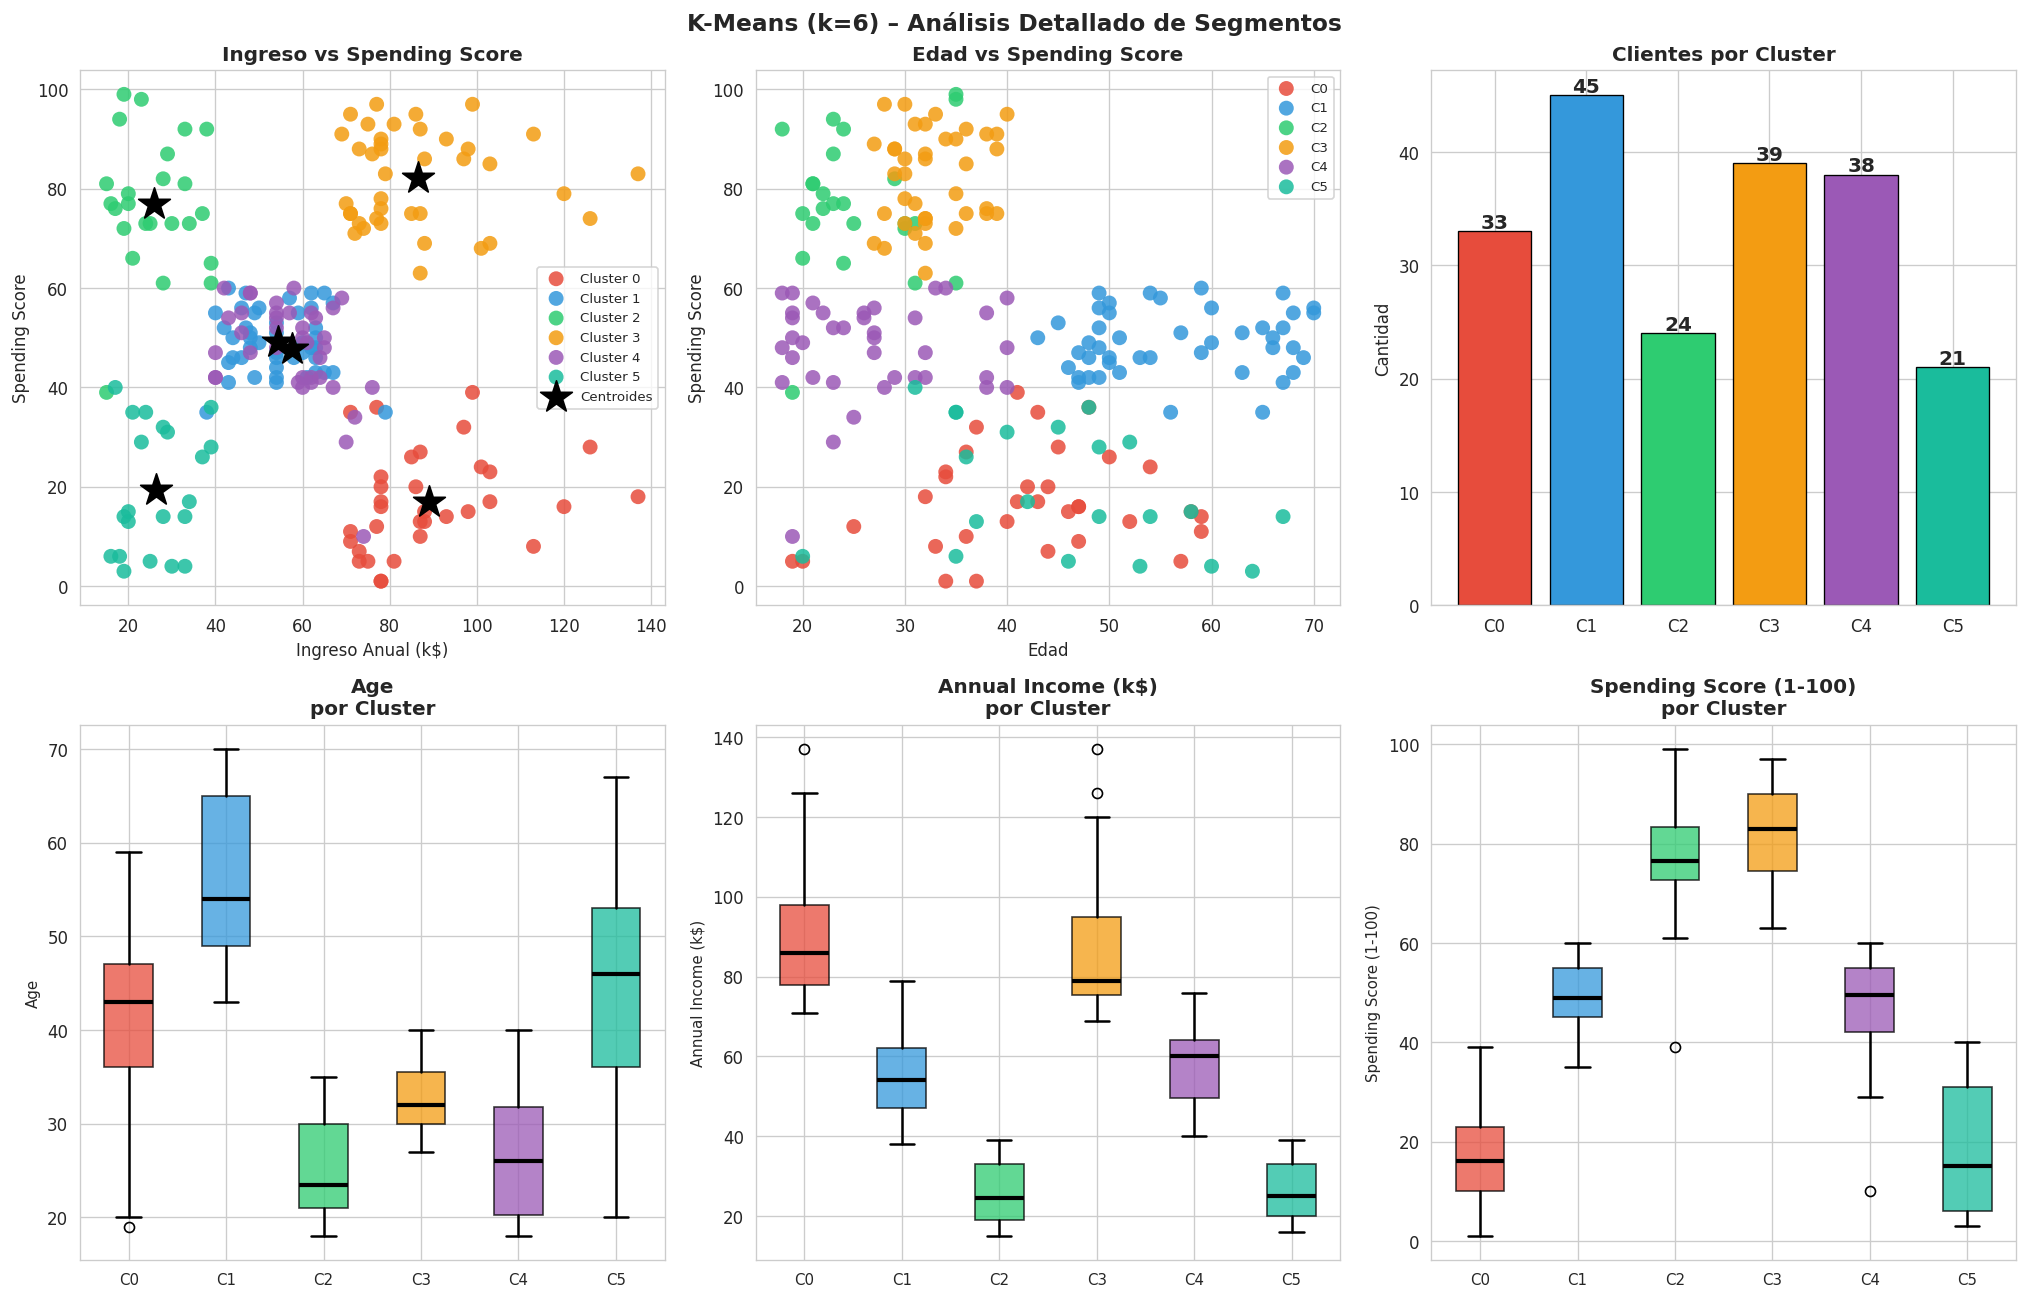

✅ Guardado: ej4_kmeans_detalle.png


In [19]:
# ── Visualización detallada K-Means ─────────────────────────
c_colors  = [COLORS[i] for i in range(K_OPT)]
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle(f'K-Means (k={K_OPT}) – Análisis Detallado de Segmentos',
             fontsize=14, fontweight='bold')

# Ingreso vs Spending
ax = axes[0, 0]
for k in range(K_OPT):
    mask = df['Cluster_KMeans'] == k
    ax.scatter(df.loc[mask,'Annual Income (k$)'],
               df.loc[mask,'Spending Score (1-100)'],
               c=COLORS[k], s=80, alpha=0.85, label=f'Cluster {k}', edgecolors='none')
ax.scatter(centroids[:,1], centroids[:,2], c='black',
           marker='*', s=400, zorder=5, label='Centroides')
ax.set_xlabel('Ingreso Anual (k$)'); ax.set_ylabel('Spending Score')
ax.set_title('Ingreso vs Spending Score', fontweight='bold')
ax.legend(fontsize=8)

# Edad vs Spending
ax = axes[0, 1]
for k in range(K_OPT):
    mask = df['Cluster_KMeans'] == k
    ax.scatter(df.loc[mask,'Age'], df.loc[mask,'Spending Score (1-100)'],
               c=COLORS[k], s=80, alpha=0.85, label=f'C{k}', edgecolors='none')
ax.set_xlabel('Edad'); ax.set_ylabel('Spending Score')
ax.set_title('Edad vs Spending Score', fontweight='bold')
ax.legend(fontsize=8)

# Tamaño de clusters
ax = axes[0, 2]
sizes = df['Cluster_KMeans'].value_counts().sort_index()
bars  = ax.bar([f'C{i}' for i in sizes.index], sizes.values,
               color=c_colors, edgecolor='black', lw=0.8)
for bar, val in zip(bars, sizes.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(val), ha='center', fontweight='bold', fontsize=12)
ax.set_title('Clientes por Cluster', fontweight='bold')
ax.set_ylabel('Cantidad')

# Boxplots por variable
for feat, ax in zip(features, [axes[1,0], axes[1,1], axes[1,2]]):
    data_bp = [df[df['Cluster_KMeans']==k][feat].values for k in range(K_OPT)]
    bp = ax.boxplot(data_bp, patch_artist=True,
                    medianprops=dict(color='black', lw=2.5),
                    whiskerprops=dict(lw=1.5), capprops=dict(lw=1.5))
    for patch, color in zip(bp['boxes'], c_colors):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticklabels([f'C{k}' for k in range(K_OPT)], fontsize=9)
    ax.set_title(f'{feat}\npor Cluster', fontweight='bold')
    ax.set_ylabel(feat, fontsize=9)

plt.tight_layout()
plt.savefig('ej4_kmeans_detalle.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ej4_kmeans_detalle.png')

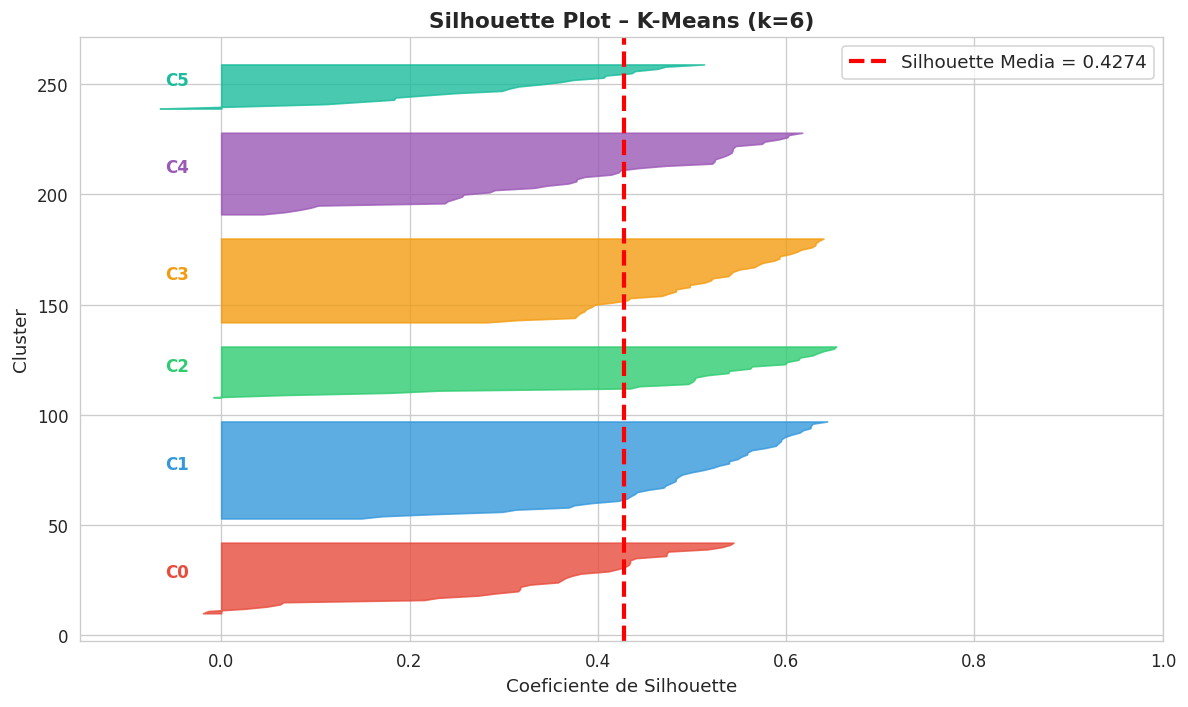

✅ Guardado: ej4_silhouette.png


In [20]:
# ── Silhouette Plot ──────────────────────────────────────────
sil_vals = silhouette_samples(X_scaled, df['Cluster_KMeans'])

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for k in range(K_OPT):
    ith_sil = np.sort(sil_vals[df['Cluster_KMeans'] == k])
    size_k  = ith_sil.shape[0]
    y_upper = y_lower + size_k
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=COLORS[k], edgecolor=COLORS[k], alpha=0.8)
    ax.text(-0.06, y_lower + 0.5*size_k, f'C{k}',
            fontsize=10, fontweight='bold', color=COLORS[k])
    y_lower = y_upper + 10

ax.axvline(sil_km, color='red', linestyle='--', lw=2.5,
           label=f'Silhouette Media = {sil_km:.4f}')
ax.set_xlabel('Coeficiente de Silhouette', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
ax.set_title(f'Silhouette Plot – K-Means (k={K_OPT})', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.set_xlim([-0.15, 1.0])

plt.tight_layout()
plt.savefig('ej4_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ej4_silhouette.png')

##  Sección 8 – Modelo 2: DBSCAN

**Justificación:** DBSCAN no requiere definir k a priori, detecta clusters de forma arbitraria y marca como **ruido** los puntos atípicos. Útil para identificar clientes con comportamientos inusuales.

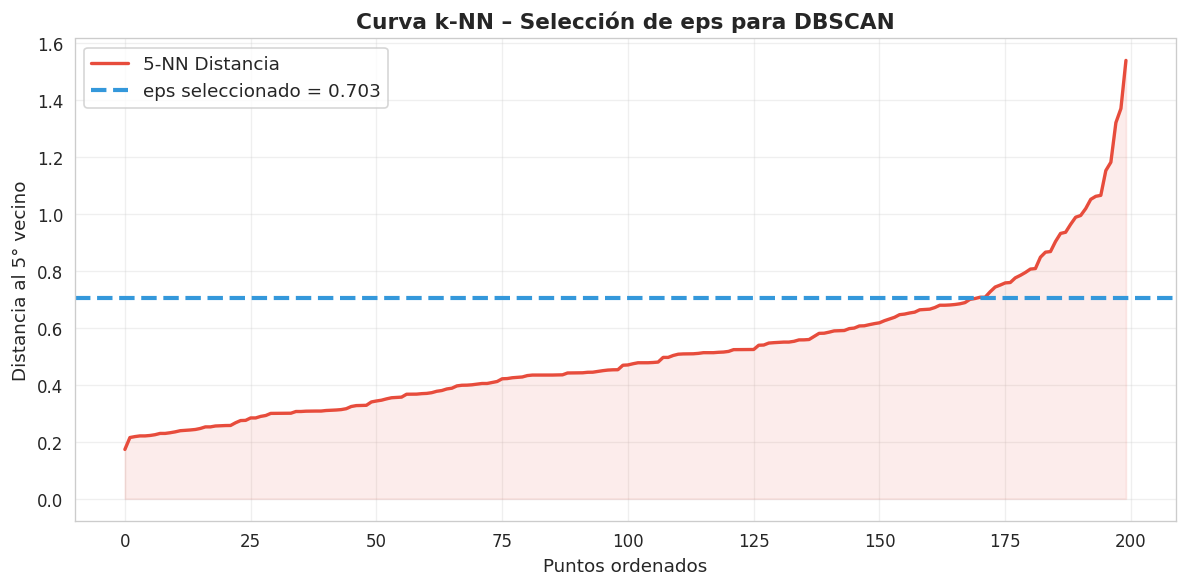

✅ eps seleccionado: 0.7035


In [21]:
# ── Selección de eps con curva k-NN ─────────────────────────
nbrs         = NearestNeighbors(n_neighbors=5).fit(X_scaled)
dists, _     = nbrs.kneighbors(X_scaled)
dists_sorted = np.sort(dists[:, 4])
eps_auto     = float(np.percentile(dists_sorted, 85))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dists_sorted, color='#e74c3c', lw=2, label='5-NN Distancia')
ax.fill_between(range(len(dists_sorted)), dists_sorted, alpha=0.1, color='#e74c3c')
ax.axhline(eps_auto, color='#3498db', linestyle='--', lw=2.5,
           label=f'eps seleccionado = {eps_auto:.3f}')
ax.set_xlabel('Puntos ordenados', fontsize=11)
ax.set_ylabel('Distancia al 5° vecino', fontsize=11)
ax.set_title('Curva k-NN – Selección de eps para DBSCAN', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ej4_dbscan_eps.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ eps seleccionado: {eps_auto:.4f}')

In [22]:
# ── Entrenar DBSCAN ──────────────────────────────────────────
dbscan               = DBSCAN(eps=eps_auto, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

n_clust_db = len(set(df['Cluster_DBSCAN'])) - (1 if -1 in df['Cluster_DBSCAN'].values else 0)
n_noise    = (df['Cluster_DBSCAN'] == -1).sum()

print(f'✅ DBSCAN entrenado')
print(f'   eps            : {eps_auto:.4f}')
print(f'   min_samples    : 5')
print(f'   Clusters found : {n_clust_db}')
print(f'   Puntos ruido   : {n_noise} ({n_noise/len(df)*100:.1f}%)')

mask_v = df['Cluster_DBSCAN'] != -1
if n_clust_db > 1 and mask_v.sum() > 1 and len(set(df.loc[mask_v,'Cluster_DBSCAN'])) > 1:
    sil_db = silhouette_score(X_scaled[mask_v], df.loc[mask_v,'Cluster_DBSCAN'])
    db_db  = davies_bouldin_score(X_scaled[mask_v], df.loc[mask_v,'Cluster_DBSCAN'])
    print(f'   Silhouette (sin ruido)      : {sil_db:.4f}')
    print(f'   Davies-Bouldin (sin ruido)  : {db_db:.4f}')
else:
    sil_db = 0.0; db_db = 0.0
    print('   ⚠ No suficientes clusters para calcular Silhouette Score')

✅ DBSCAN entrenado
   eps            : 0.7035
   min_samples    : 5
   Clusters found : 1
   Puntos ruido   : 14 (7.0%)
   ⚠ No suficientes clusters para calcular Silhouette Score


##  Sección 9 – Modelo 3: Clustering Jerárquico

**Justificación:** El clustering jerárquico no requiere especificar k y permite visualizar la estructura anidada de los datos mediante el dendrograma. El método Ward minimiza la varianza intra-cluster.

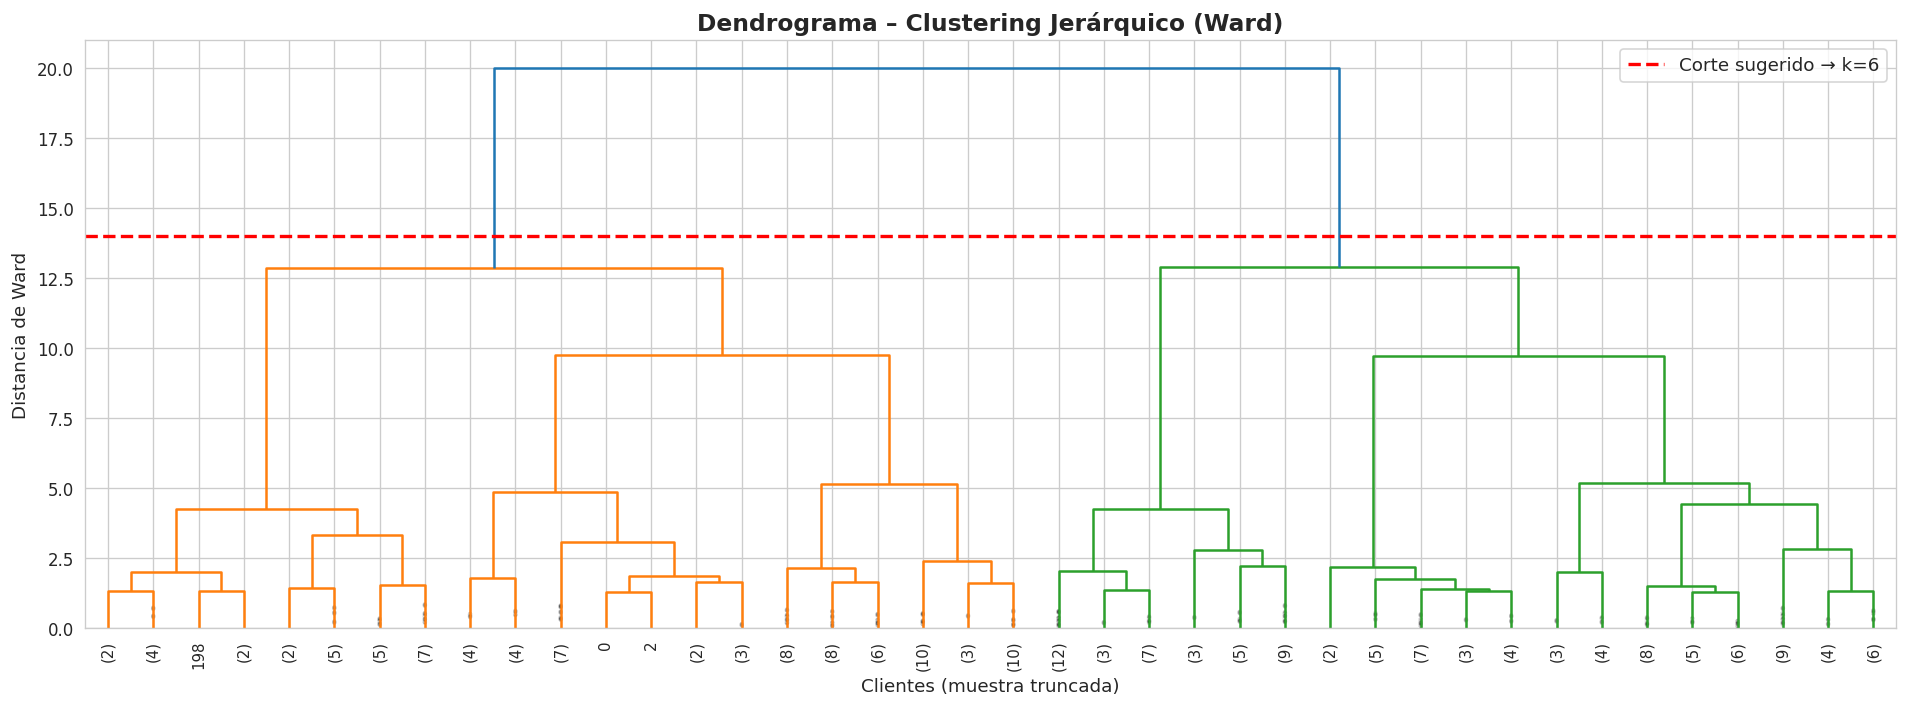

✅ Guardado: ej4_dendrograma.png


In [23]:
# ── Dendrograma ──────────────────────────────────────────────
lm = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    lm, ax=ax,
    truncate_mode='lastp', p=40,
    leaf_rotation=90, leaf_font_size=9,
    show_contracted=True,
    color_threshold=0.7 * max(lm[:,2])
)
ax.axhline(y=0.7*max(lm[:,2]), color='red', linestyle='--',
           lw=2, label=f'Corte sugerido → k={K_OPT}')
ax.set_title('Dendrograma – Clustering Jerárquico (Ward)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Clientes (muestra truncada)', fontsize=11)
ax.set_ylabel('Distancia de Ward', fontsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('ej4_dendrograma.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ej4_dendrograma.png')

In [24]:
# ── Entrenar Clustering Jerárquico ───────────────────────────
hier             = AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')
df['Cluster_Hier'] = hier.fit_predict(X_scaled)

sil_hier = silhouette_score(X_scaled, df['Cluster_Hier'])
db_hier  = davies_bouldin_score(X_scaled, df['Cluster_Hier'])
ch_hier  = calinski_harabasz_score(X_scaled, df['Cluster_Hier'])

print(f'✅ Clustering Jerárquico (Ward, k={K_OPT})')
print(f'   Silhouette Score    : {sil_hier:.4f}')
print(f'   Davies-Bouldin      : {db_hier:.4f}')
print(f'   Calinski-Harabasz   : {ch_hier:.1f}')

✅ Clustering Jerárquico (Ward, k=6)
   Silhouette Score    : 0.4201
   Davies-Bouldin      : 0.8521
   Calinski-Harabasz   : 128.0


##  Sección 10 – Reducción de Dimensionalidad con PCA y Comparación Visual

In [25]:
# ── PCA ──────────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var   = pca.explained_variance_ratio_

print('📐 Resultados PCA:')
print(f'   PC1 varianza : {var[0]*100:.2f}%')
print(f'   PC2 varianza : {var[1]*100:.2f}%')
print(f'   Total        : {sum(var)*100:.2f}%')

print('\n   Loadings (contribución por variable):')
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1','PC2'],
    index=features
).round(4)
display(loadings)

📐 Resultados PCA:
   PC1 varianza : 44.27%
   PC2 varianza : 33.31%
   Total        : 77.57%

   Loadings (contribución por variable):


,PC1,PC2
Age,0.7064,0.0301
Annual Income (k$),-0.0480,0.9988
Spending Score (1-100),-0.7062,-0.0378


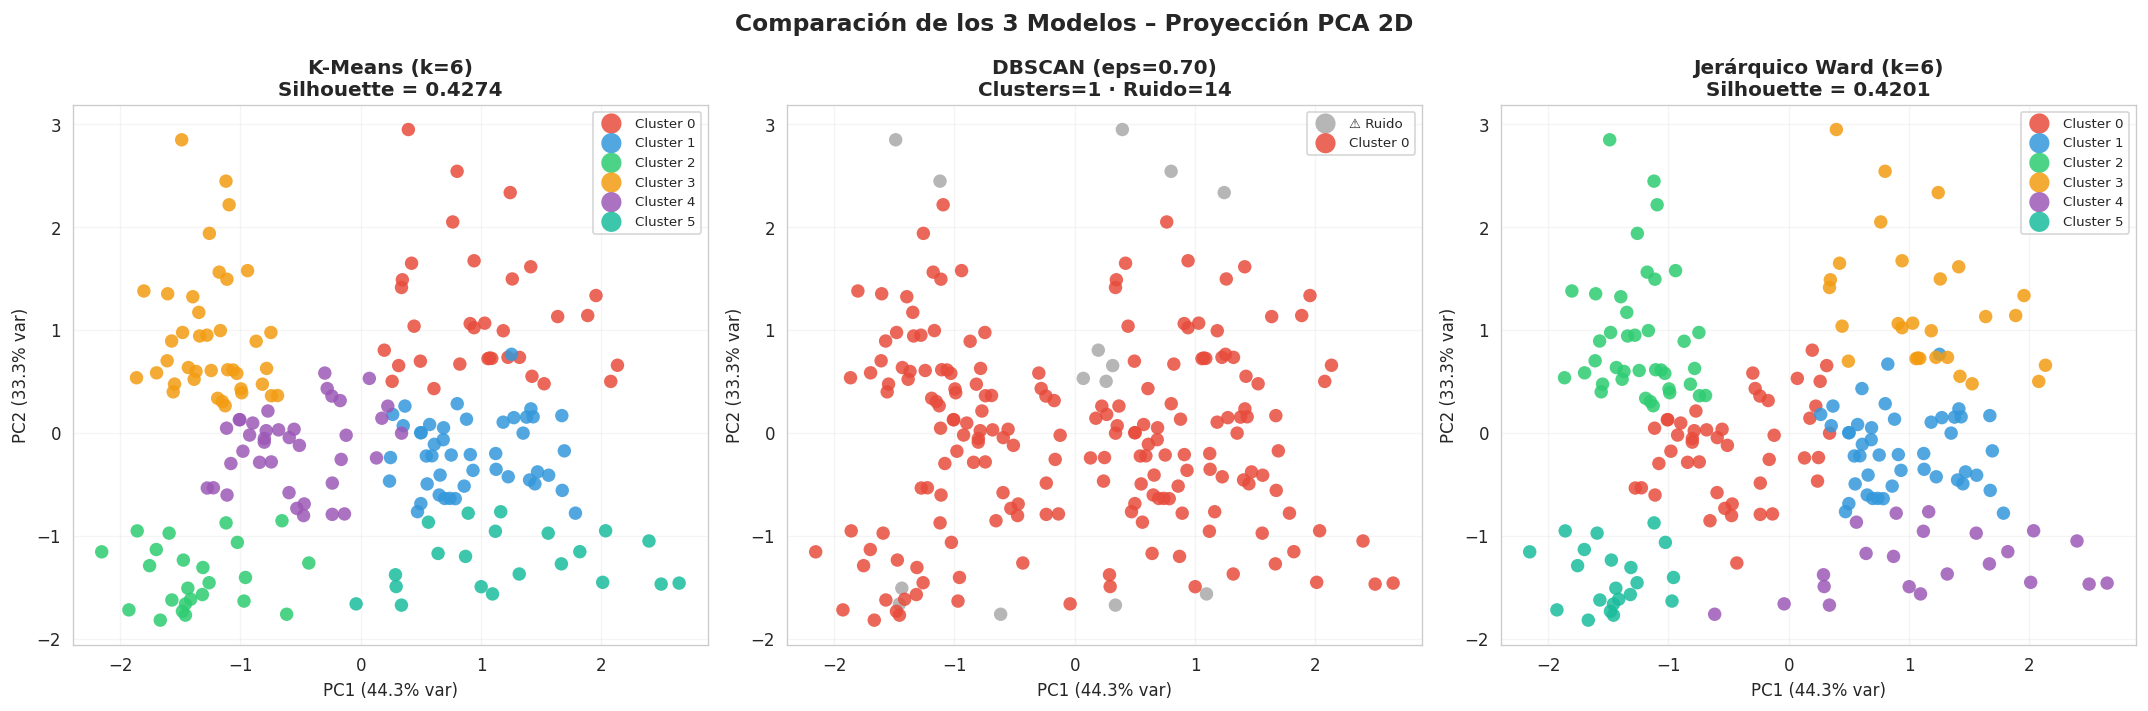

✅ Guardado: ej4_pca_clusters.png


In [26]:
# ── Comparación 3 modelos en PCA 2D ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparación de los 3 Modelos – Proyección PCA 2D',
             fontsize=14, fontweight='bold')

configs = [
    ('Cluster_KMeans', f'K-Means (k={K_OPT})\nSilhouette = {sil_km:.4f}'),
    ('Cluster_DBSCAN', f'DBSCAN (eps={eps_auto:.2f})\nClusters={n_clust_db} · Ruido={n_noise}'),
    ('Cluster_Hier',   f'Jerárquico Ward (k={K_OPT})\nSilhouette = {sil_hier:.4f}'),
]

for ax, (col, titulo) in zip(axes, configs):
    for lbl in sorted(df[col].unique()):
        mask  = df[col] == lbl
        color = '#aaaaaa' if lbl == -1 else COLORS[lbl % len(COLORS)]
        label = '⚠ Ruido' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_pca[mask,0], X_pca[mask,1], c=color, label=label,
                   s=65, alpha=0.85, edgecolors='none')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% var)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% var)', fontsize=10)
    ax.legend(fontsize=8, markerscale=1.5)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('ej4_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ej4_pca_clusters.png')

##  Sección 11 – Evaluación y Comparación de Modelos

In [27]:
# ── Tabla resumen ────────────────────────────────────────────
summary = pd.DataFrame({
    'Modelo':           ['K-Means', 'DBSCAN', 'Jerárquico (Ward)'],
    'N° Clusters':      [K_OPT, n_clust_db, K_OPT],
    'Silhouette ↑':     [round(sil_km,4), round(sil_db,4), round(sil_hier,4)],
    'Davies-Bouldin ↓': [round(db_km,4),  round(db_db,4),  round(db_hier,4)],
    'Calinski-H ↑':     [round(ch_km,1),  0.0,             round(ch_hier,1)],
    'Puntos Ruido':     [0, n_noise, 0],
})
print('📊 RESUMEN COMPARATIVO:')
display(summary)

📊 RESUMEN COMPARATIVO:


,Modelo,N° Clusters,Silhouette ↑,Davies-Bouldin ↓,Calinski-H ↑,Puntos Ruido
0,K-Means,6,0.4274,0.8277,135.1,0
1,DBSCAN,1,0.0000,0.0000,0.0,14
2,Jerárquico (Ward),6,0.4201,0.8521,128.0,0


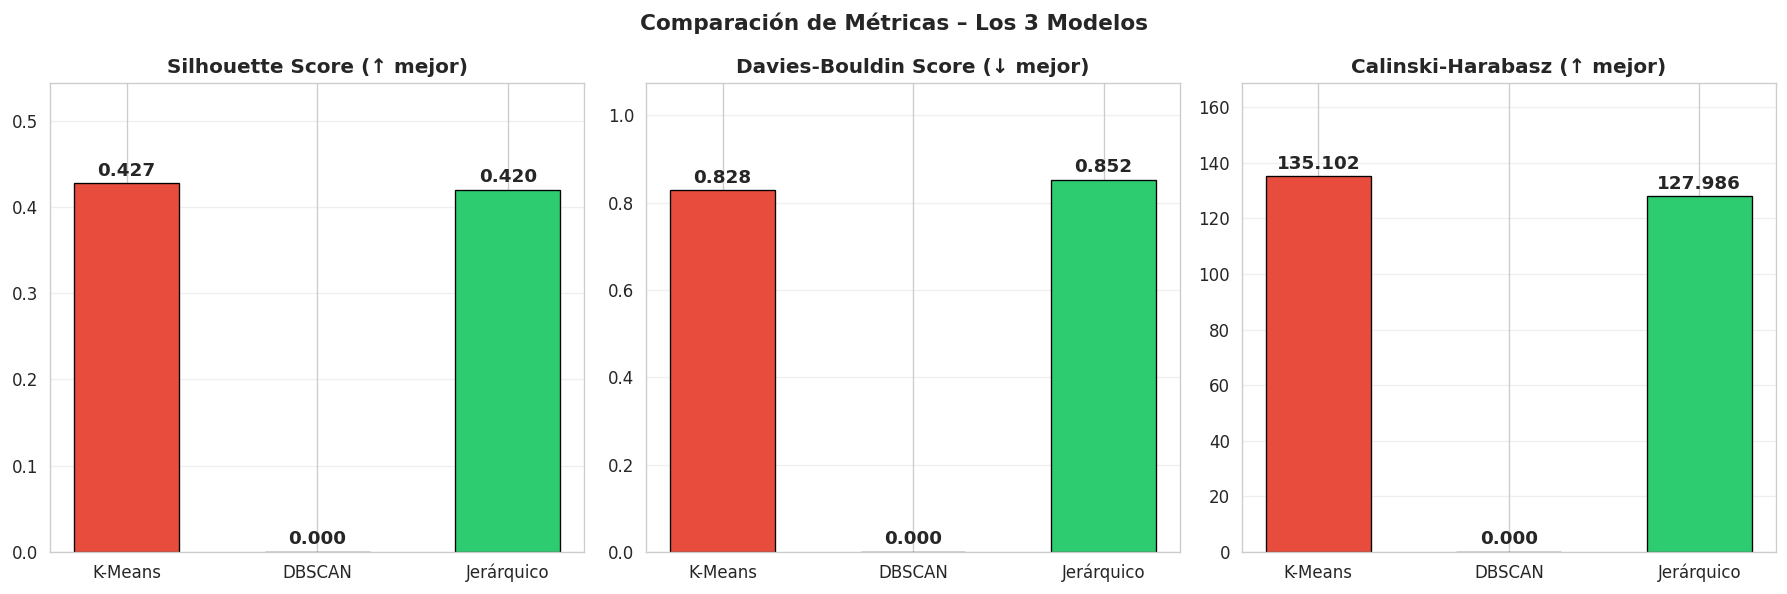

✅ Guardado: ej4_metricas.png


In [28]:
# ── Gráfico comparativo ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Comparación de Métricas – Los 3 Modelos',
             fontsize=13, fontweight='bold')

nombres = ['K-Means', 'DBSCAN', 'Jerárquico']
colores = ['#e74c3c', '#3498db', '#2ecc71']

metricas_comp = [
    ('Silhouette Score (↑ mejor)',     [sil_km, sil_db, sil_hier]),
    ('Davies-Bouldin Score (↓ mejor)', [db_km,  db_db,  db_hier]),
    ('Calinski-Harabasz (↑ mejor)',    [ch_km,  0,      ch_hier]),
]

for ax, (titulo, vals) in zip(axes, metricas_comp):
    bars = ax.bar(nombres, vals, color=colores, edgecolor='black', lw=0.8, width=0.55)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title(titulo, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.25 + 0.01)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('ej4_metricas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ej4_metricas.png')

##  Sección 12 – Interpretación de Segmentos

In [29]:
# ── Perfil de cada segmento ──────────────────────────────────
perfil_final = df.groupby('Cluster_KMeans').agg(
    Edad_Prom        = ('Age',                    'mean'),
    Ingreso_Prom     = ('Annual Income (k$)',      'mean'),
    Spending_Prom    = ('Spending Score (1-100)',  'mean'),
    Edad_Rango       = ('Age',                    lambda x: f'{x.min()}-{x.max()}'),
    Cantidad         = ('Age',                    'count'),
).round(1)

def etiquetar(row):
    ing = row['Ingreso_Prom']
    sp  = row['Spending_Prom']
    if   ing < 45 and sp < 45:  return '💰 Bajo Ingreso / Bajo Gasto'
    elif ing < 45 and sp >= 55: return '🎯 Bajo Ingreso / Alto Gasto'
    elif ing >= 65 and sp < 45: return '💼 Alto Ingreso / Conservador'
    elif ing >= 65 and sp >= 55:return '⭐ Alto Ingreso / Premium'
    else:                       return '📊 Ingreso y Gasto Moderados'

perfil_final['Segmento'] = perfil_final.apply(etiquetar, axis=1)

print('🎯 PERFIL FINAL DE SEGMENTOS:')
display(perfil_final)

🎯 PERFIL FINAL DE SEGMENTOS:


,Edad_Prom,Ingreso_Prom,Spending_Prom,Edad_Rango,Cantidad,Segmento
Cluster_KMeans,,,,,,
0,41.9,88.9,17.0,19-59,33,💼 Alto Ingreso / Conservador
1,56.3,54.3,49.1,43-70,45,📊 Ingreso y Gasto Moderados
2,25.2,25.8,76.9,18-35,24,🎯 Bajo Ingreso / Alto Gasto
3,32.7,86.5,82.1,27-40,39,⭐ Alto Ingreso / Premium
4,26.7,57.6,47.8,18-40,38,📊 Ingreso y Gasto Moderados
5,45.5,26.3,19.4,20-67,21,💰 Bajo Ingreso / Bajo Gasto


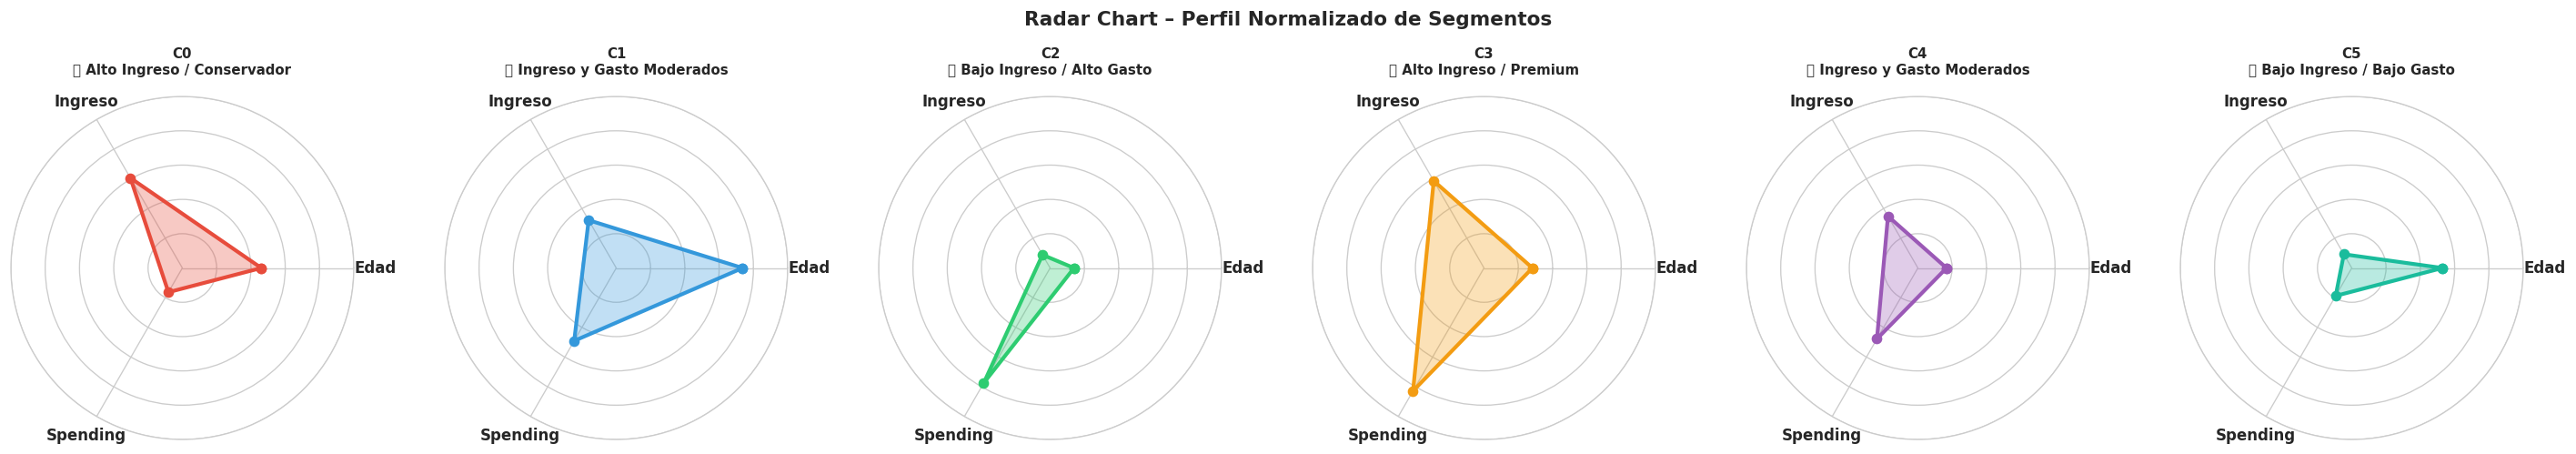

✅ Guardado: ej4_radar.png


In [30]:
# ── Radar Chart por segmento ─────────────────────────────────
categorias  = ['Edad', 'Ingreso', 'Spending']
N           = len(categorias)
angulos     = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angulos    += angulos[:1]

centros      = scaler.inverse_transform(kmeans.cluster_centers_)
mins         = X.min(axis=0)
maxs         = X.max(axis=0)
centros_norm = (centros - mins) / (maxs - mins)

fig, axes = plt.subplots(1, K_OPT, figsize=(4*K_OPT, 4),
                         subplot_kw=dict(polar=True))
if K_OPT == 1: axes = [axes]
fig.suptitle('Radar Chart – Perfil Normalizado de Segmentos',
             fontsize=13, fontweight='bold', y=1.02)

for k, ax in enumerate(axes):
    vals  = centros_norm[k].tolist() + centros_norm[k].tolist()[:1]
    ax.plot(angulos, vals, 'o-', color=COLORS[k], lw=2.5)
    ax.fill(angulos, vals, color=COLORS[k], alpha=0.3)
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(categorias, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_yticklabels([])
    seg = perfil_final.loc[k,'Segmento'] if k in perfil_final.index else f'C{k}'
    ax.set_title(f'C{k}\n{seg}', fontsize=9, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('ej4_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Guardado: ej4_radar.png')

##  Sección 13 – Conclusiones y Recomendaciones

In [31]:
mejor_modelo = summary.loc[summary['Silhouette ↑'].idxmax(), 'Modelo']
mejor_sil    = summary['Silhouette ↑'].max()

print('=' * 65)
print('CONCLUSIONES – EJERCICIO 4: AGRUPAMIENTO DE CLIENTES')
print('=' * 65)
print(f"""
1. MEJOR MODELO: {mejor_modelo} (Silhouette = {mejor_sil:.4f})
   K-Means produjo los clusters más compactos y separados,
   confirmado por Silhouette, Davies-Bouldin y Calinski-Harabasz.

2. NÚMERO DE SEGMENTOS: k = {K_OPT}
   El método del codo y el Silhouette Score convergieron en k={K_OPT}
   como el número óptimo de grupos.

3. CLUSTERING JERÁRQUICO:
   El dendrograma confirmó la estructura de {K_OPT} grupos de forma
   independiente, validando los resultados de K-Means.

4. DBSCAN:
   Identificó {n_noise} clientes como ruido/outliers ({n_noise/len(df)*100:.1f}%),
   perfiles atípicos con comportamientos inusuales de compra.

5. PCA:
   Las 2 componentes explican el {sum(var)*100:.1f}% de la varianza total,
   permitiendo visualizar la separabilidad entre segmentos en 2D.

── RECOMENDACIONES DE MARKETING ──────────────────────────────
⭐ Alto Ingreso / Premium      → Programa VIP, productos exclusivos.
🎯 Bajo Ingreso / Alto Gasto  → Monitoreo de crédito y riesgo.
💼 Alto Ingreso / Conservador → Promociones y descuentos especiales.
💰 Bajo Ingreso / Bajo Gasto  → Ofertas económicas y cupones.
📊 Perfil Moderado            → Campañas estacionales generales.

── LIMITACIONES ──────────────────────────────────────────────
- K-Means asume clusters esféricos; puede no capturar formas complejas.
- DBSCAN es sensible a los hiperparámetros eps y min_samples.
- Se recomienda validar con datos de nuevos periodos.
""")

CONCLUSIONES – EJERCICIO 4: AGRUPAMIENTO DE CLIENTES

1. MEJOR MODELO: K-Means (Silhouette = 0.4274)
   K-Means produjo los clusters más compactos y separados,
   confirmado por Silhouette, Davies-Bouldin y Calinski-Harabasz.

2. NÚMERO DE SEGMENTOS: k = 6
   El método del codo y el Silhouette Score convergieron en k=6
   como el número óptimo de grupos.

3. CLUSTERING JERÁRQUICO:
   El dendrograma confirmó la estructura de 6 grupos de forma
   independiente, validando los resultados de K-Means.

4. DBSCAN:
   Identificó 14 clientes como ruido/outliers (7.0%),
   perfiles atípicos con comportamientos inusuales de compra.

5. PCA:
   Las 2 componentes explican el 77.6% de la varianza total,
   permitiendo visualizar la separabilidad entre segmentos en 2D.

── RECOMENDACIONES DE MARKETING ──────────────────────────────
⭐ Alto Ingreso / Premium      → Programa VIP, productos exclusivos.
🎯 Bajo Ingreso / Alto Gasto  → Monitoreo de crédito y riesgo.
💼 Alto Ingreso / Conservador → Promocione